In [115]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
df = pd.read_csv("/Users/jana/Documents/Summer 2026/IAT461/youtube_videos.csv")

In [116]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [117]:
scaler = MinMaxScaler()

In [118]:
df["subcribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

In [119]:
df["subcribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subcribers_minmax, dtype: float64

In [120]:
standard_scaler = StandardScaler()

In [121]:
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [122]:
df[["views", "view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [123]:
df["likes_minmax"] = scaler.fit_transform(df[["likes"]])

In [124]:
df["likes_minmax"].describe()

count    210.000000
mean       0.056527
std        0.145500
min        0.000000
25%        0.001001
50%        0.004769
75%        0.027410
max        1.000000
Name: likes_minmax, dtype: float64

In [125]:
df["like_zscore"] = standard_scaler.fit_transform(df[["likes"]])

In [126]:
df[["likes", "like_zscore"]].describe()

,likes,like_zscore
count,210.000000,2.100000e+02
mean,25765.304762,8.458842e-18
std,66234.880530,1.002389e+00
min,33.000000,-3.894291e-01
25%,488.750000,-3.825319e-01
50%,2204.000000,-3.565735e-01
75%,12510.750000,-2.005926e-01
max,455256.000000,6.499853e+00


In [161]:
robust_scaler = RobustScaler()
df["like_robust"] = robust_scaler.fit_transform(df[["likes"]])

In [163]:
df["like_robust"].describe()

count    210.000000
mean       1.959849
std        5.509473
min       -0.180586
25%       -0.142676
50%        0.000000
75%        0.857324
max       37.685244
Name: like_robust, dtype: float64

In [127]:
df["view_logs"] = np.log1p(df["views"]) 

<Axes: xlabel='view_logs', ylabel='Count'>

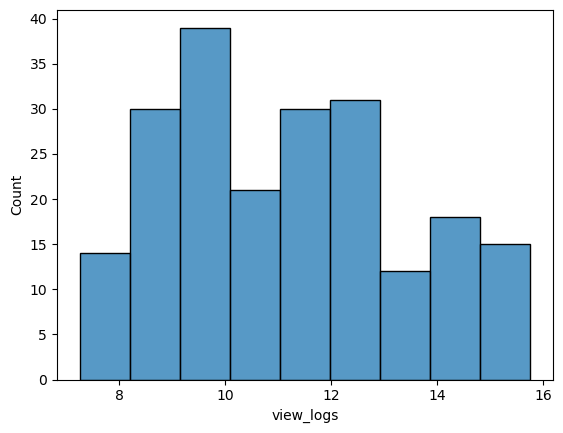

In [128]:
sns.histplot(df["view_logs"])

In [129]:
bins = [0, 300, 2000, float("inf")]
labels = ['short', 'medium', 'long']

df["duration_bin"] = pd.cut(df["duration_seconds"], bins = bins, labels = labels)

<Axes: xlabel='duration_bin', ylabel='count'>

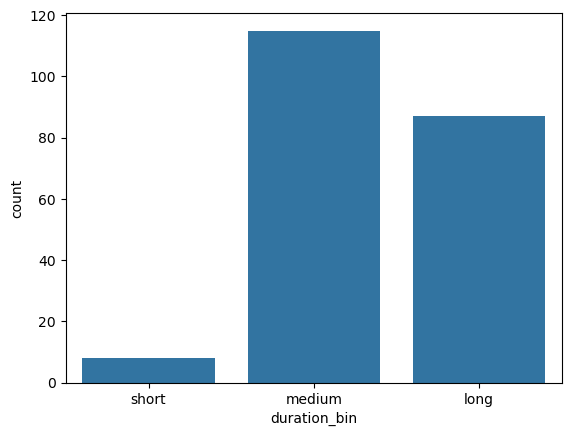

In [130]:
sns.countplot(x="duration_bin", data= df)

<Axes: xlabel='likes_logs', ylabel='Count'>

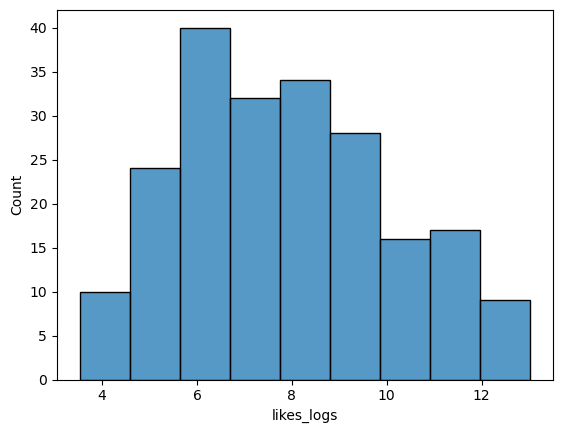

In [131]:
df["likes_logs"] = np.log1p(df["likes"]) 
sns.histplot(df["likes_logs"])

In [140]:
bins = [0, 2, 5, float("inf")]
labels = ['short', 'medium', 'long']

df["channel_age_years_bin"] = pd.cut(df["channel_age_years"], bins = bins, labels = labels)

<Axes: xlabel='channel_age_years_bin', ylabel='count'>

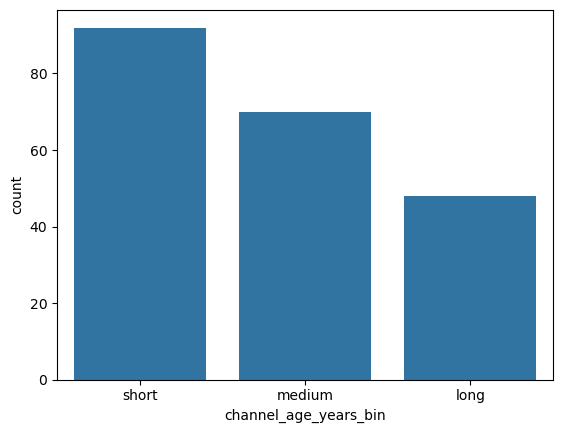

In [141]:
sns.countplot(x="channel_age_years_bin", data= df)

In [142]:
df["channel_tier"].unique()

array(['Mid', 'Small', 'Large'], dtype=object)

In [143]:
encoder = OrdinalEncoder(categories=[["Mid", "Small", "Large"]]) 
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)  

In [144]:
dummyVars = pd.get_dummies(df["category"], prefix="is")

In [145]:
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [146]:
df = pd.concat([df,dummyVars], axis = 1)

In [147]:
df

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,is_Gaming,is_Music,is_News,is_Vlog,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,False,True,False,False,False,False,False,True,False,False
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,True,False,False,False,False,False,True,False,False,False
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,True,False,False,False,False,False,True,False,False,False
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,True,False,False,False,False,False,True,False,False,False
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,False,False,False,False,False,True,False,False,False,False
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,False,False,True,False,False,False,False,False,True,False
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,True,False,False,False,False,False,True,False,False,False
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,False,False,False,False,True,False,False,False,False,False


In [150]:
df["caps_count"] = df["title"].apply(
    lambda t: sum( 1 for w in t.split() if w.isupper())
)

In [151]:
df["caps_count"]

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: caps_count, Length: 210, dtype: int64

In [155]:
def countCaps(t) :
    sum = 0
    words = t.split()
    for word in words:
        if word.isupper():
            sum = sum+1
            return sum

In [159]:
df["duration_minutes"] = df["duration_seconds"] /60
df["retention_rate"] = df["watch_time_minutes"] / df["views"] * df["duration_minutes"]

In [160]:
df["retention_rate"]

0        57.479675
1       533.476415
2       230.397493
3       239.187500
4      1098.281107
          ...     
205     393.717303
206    2679.412100
207     942.846639
208    1964.083102
209      77.846350
Name: retention_rate, Length: 210, dtype: float64